In [1]:
from pathlib import Path
import os
import sys

import pickle
import pandas as pd
import numpy as np
import json
from tqdm import tqdm
from matplotlib import pyplot as plt

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), ".."))
from syto.data.omics_signatures_handlers.binary_cpg_signature import BinaryCpGSignatureHandler

In [2]:
labels_dict = json.load(open("../../App/labels_dict.json", "r", encoding="utf-8"))

In [3]:
dismir_soft_test_pred_path = Path("../../Data/extended_proportions/Dismir_soft_labels_pooled/test_predicted.pkl")
dismir_soft_test_pred = pd.read_pickle(dismir_soft_test_pred_path)

In [5]:
MAX_LEN_DISMIR = 150
# to understand how the dismir model performed, we transfrom the dna and methylation data to
# what the dismir model saw during inference, ie the clipped sequences
dismir_soft_test_pred["pattern"] = dismir_soft_test_pred["pattern"].apply(lambda x: x[:MAX_LEN_DISMIR])
dismir_soft_test_pred["seq"] = dismir_soft_test_pred["seq"].apply(lambda x: x[:MAX_LEN_DISMIR])

In [7]:
binary_cpg_signature_handler = BinaryCpGSignatureHandler(start_column="trimmed_start", methylation_pattern_column="pattern")
if "sig" not in dismir_soft_test_pred.columns:
    tqdm.pandas(desc="Extracting signature")
    dismir_soft_test_pred["sig"] = dismir_soft_test_pred.progress_apply(binary_cpg_signature_handler.extract_signature, axis=1)

Extracting signature: 100%|██████████| 900610/900610 [00:13<00:00, 64482.72it/s]


For each signature, we compute:
- the number of reads with that signature
- for every prediction column:
  - the min prediction value among reads with that signature
  - the max prediction value among reads with that signature
  - the mean prediction value among reads with that signature
  - the spread (max - min) of prediction values among reads with that signature

In [8]:
agg_dict = {}
for col in dismir_soft_test_pred.columns:
    if col.startswith("prediction"):
        agg_dict[f"{col}_min"] = (col, "min")
        agg_dict[f"{col}_max"] = (col, "max")
        agg_dict[f"{col}_mean"] = (col, "mean")
agg_dict["soft_label"] = ("soft_label", "first")
agg_dict["num_reads"] = ("soft_label", "count")
sig_df = dismir_soft_test_pred.groupby(["chr", "sig"]).agg(**agg_dict)

# compute the spread (max - min) for each prediction column
for col in dismir_soft_test_pred.columns:
    if col.startswith("prediction"):
        sig_df[f"{col}_spread"] = sig_df[f"{col}_max"] - sig_df[f"{col}_min"]

sig_df["summed_spread"] = sig_df[[col for col in sig_df.columns if col.endswith("_spread")]].sum(axis=1)

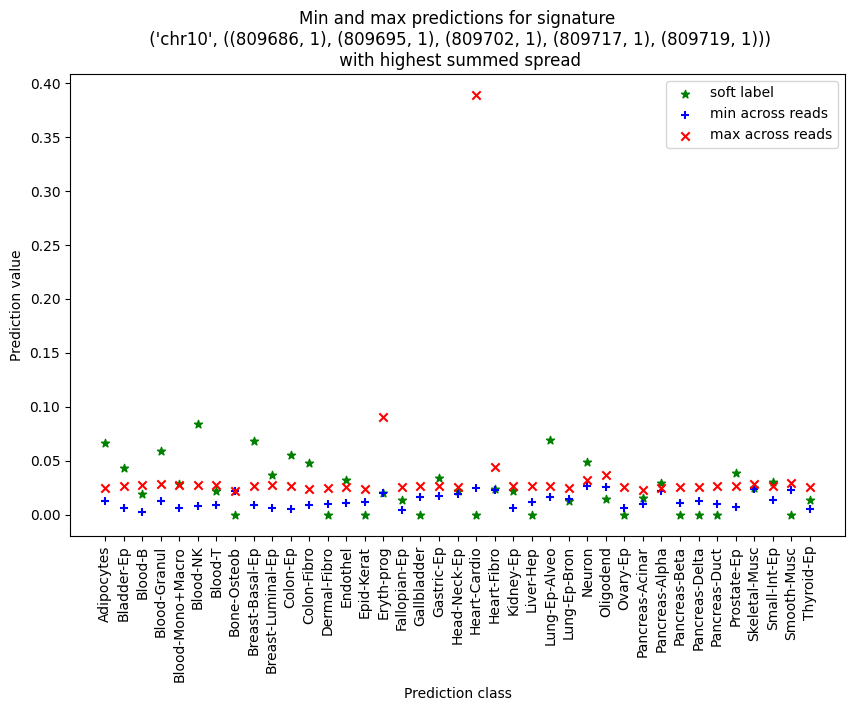

In [9]:
# for the signature with the highest summed spread, plot the envelop of the predictions for each prediction column
max_spread_sig_series = sig_df.loc[sig_df["summed_spread"] == sig_df["summed_spread"].max()].squeeze()

plt.figure(figsize=(10, 6))
num_classes = 39
x = np.arange(num_classes)
min_array = np.zeros(num_classes)
max_array = np.zeros(num_classes)
for i in range(num_classes):
    min_array[i] = max_spread_sig_series[f"prediction_{i}_min"]
    max_array[i] = max_spread_sig_series[f"prediction_{i}_max"]

plt.scatter(x, max_spread_sig_series["soft_label"], label="soft label", color="green", marker="*")
plt.scatter(x, min_array, label="min across reads", color="blue", marker="+")
plt.scatter(x, max_array, label="max across reads", color="red", marker="x")
plt.xticks(x, labels_dict.values(), rotation=90)
plt.title(f"Min and max predictions for signature\n {max_spread_sig_series.name}\n with highest summed spread")
plt.xlabel("Prediction class")
plt.ylabel("Prediction value")
plt.legend()
plt.show()

In [22]:
# analysis of the reads that creates the highest spread
sig_max_spread = sig_df.loc[sig_df["summed_spread"] == sig_df["summed_spread"].max()].reset_index()
class_max_spread = sig_max_spread[[col for col in sig_max_spread.columns if col.startswith("prediction") and col.endswith("_spread")]].idxmax(axis=1).values[0]
class_max_spread = int(class_max_spread.split("_")[1]) # extract the class number from the column name "prediction_{class}_spread"
# get the reads that belong to this signature
reads_max_spread = dismir_soft_test_pred.loc[dismir_soft_test_pred["sig"] == sig_max_spread["sig"].values[0]]
col_class_max_spread = f"prediction_{class_max_spread}"
reads_min_pred_on_class_max_spread = reads_max_spread.loc[reads_max_spread[col_class_max_spread] == reads_max_spread[col_class_max_spread].min()]
reads_max_pred_on_class_max_spread = reads_max_spread.loc[reads_max_spread[col_class_max_spread] == reads_max_spread[col_class_max_spread].max()]
print(f"{len(reads_min_pred_on_class_max_spread)} reads have the minimum prediction on class {labels_dict[str(class_max_spread)]} for signature {sig_max_spread['sig'].values[0]}")
print(f"{len(reads_max_pred_on_class_max_spread)} reads have the maximum prediction on class {labels_dict[str(class_max_spread)]} for signature {sig_max_spread['sig'].values[0]}")

86 reads have the minimum prediction on class Heart-Cardio for signature ((809686, 1), (809695, 1), (809702, 1), (809717, 1), (809719, 1))
1 reads have the maximum prediction on class Heart-Cardio for signature ((809686, 1), (809695, 1), (809702, 1), (809717, 1), (809719, 1))


In [11]:
reads_min_pred_on_class_max_spread["seq"].str.len().value_counts().sort_index()

seq
36     1
39     2
40     1
41     1
43     1
45     1
47     2
48     1
49     1
50    75
Name: count, dtype: int64

In [12]:
len(reads_max_pred_on_class_max_spread.iloc[0]["seq"])

103

In [13]:
reads_max_pred_on_class_max_spread

,chr,read_name,trimmed_start,trimmed_end,pattern,seq,name,region_start,region_end,original_label,...,prediction_30,prediction_31,prediction_32,prediction_33,prediction_34,prediction_35,prediction_36,prediction_37,prediction_38,sig
70442,chr10,11693465,809686,809789,1222222221222222122222222222222121222222222222...,CGAAACCCTCGAGGAGCGACCACATGACCCCCGCGCTGTGAGCTGC...,chr10:809687-809932,809686,809932,35,...,0.022386,0.010651,0.012433,0.009868,0.00767,0.028607,0.013626,0.029098,0.005322,"((809686, 1), (809695, 1), (809702, 1), (80971..."


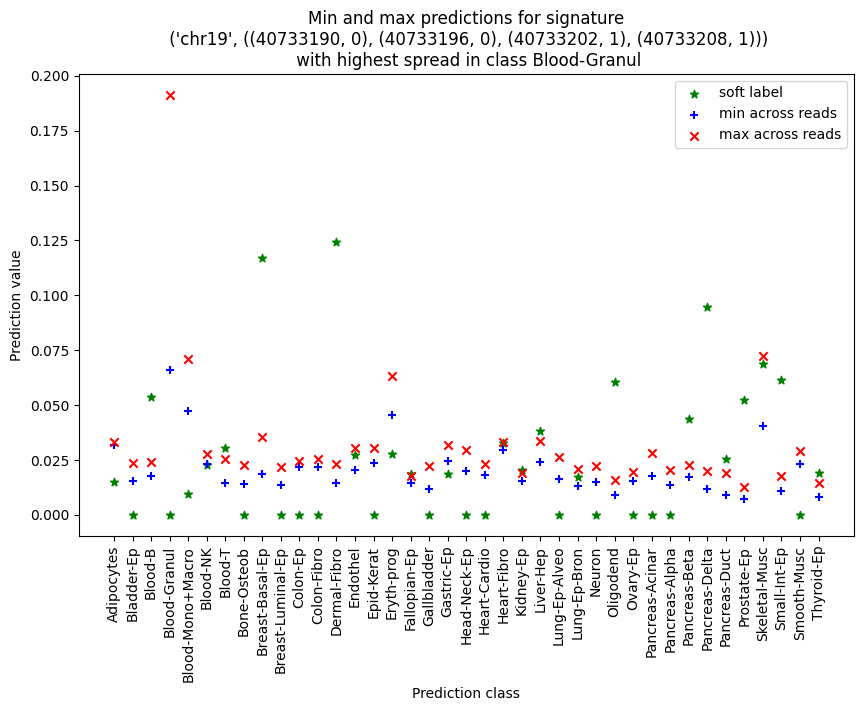

In [15]:
# for the signature with the highest summed spread, plot the envelop of the predictions for each prediction column
num_classes = 39
class_with_max_spread = 3
max_spread_sig_series = sig_df.loc[sig_df[f"prediction_{class_with_max_spread}_spread"] == sig_df[f"prediction_{class_with_max_spread}_spread"].max()].squeeze()

plt.figure(figsize=(10, 6))
x = np.arange(num_classes)
min_array = np.zeros(num_classes)
max_array = np.zeros(num_classes)
for i in range(num_classes):
    min_array[i] = max_spread_sig_series[f"prediction_{i}_min"]
    max_array[i] = max_spread_sig_series[f"prediction_{i}_max"]

plt.scatter(x, max_spread_sig_series["soft_label"], label="soft label", color="green", marker="*")
plt.scatter(x, min_array, label="min across reads", color="blue", marker="+")
plt.scatter(x, max_array, label="max across reads", color="red", marker="x")
plt.title(f"Min and max predictions for signature\n {max_spread_sig_series.name}\n with highest spread in class {labels_dict[str(class_with_max_spread)]}")
plt.xticks(x, labels_dict.values(), rotation=90)
plt.xlabel("Prediction class")
plt.ylabel("Prediction value")
plt.legend()
plt.show()

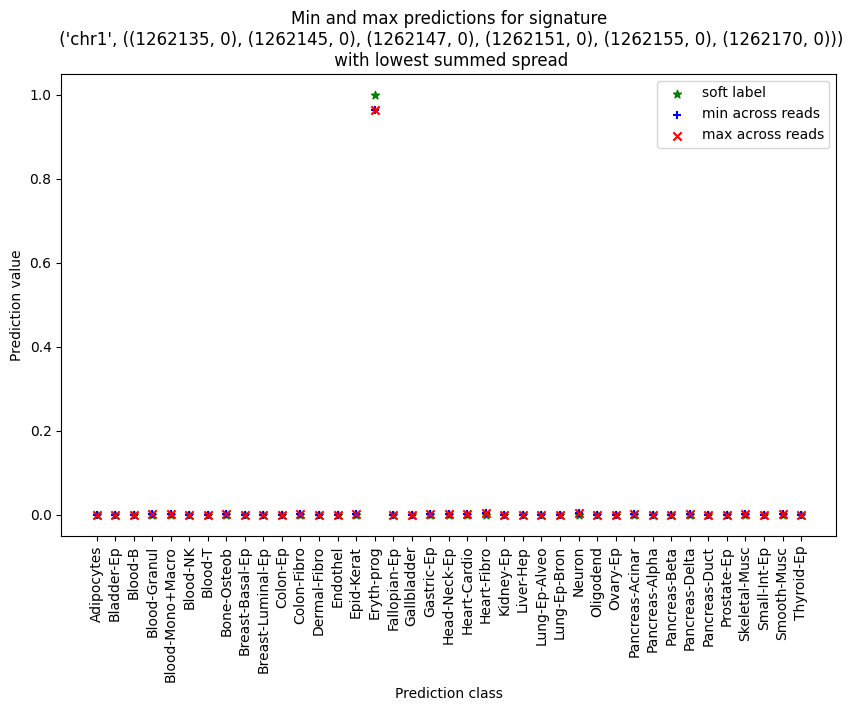

In [16]:
# for the signature with the lowest summed spread, plot the envelop of the predictions for each prediction column
min_spread_sig_series = sig_df.loc[sig_df["summed_spread"] == sig_df["summed_spread"].min()].iloc[0].squeeze()

plt.figure(figsize=(10, 6))
num_classes = 39
x = np.arange(num_classes)
min_array = np.zeros(num_classes)
max_array = np.zeros(num_classes)
for i in range(num_classes):
    min_array[i] = min_spread_sig_series[f"prediction_{i}_min"]
    max_array[i] = min_spread_sig_series[f"prediction_{i}_max"]

plt.scatter(x, min_spread_sig_series["soft_label"], label="soft label", color="green", marker="*")
plt.scatter(x, min_array, label="min across reads", color="blue", marker="+")
plt.scatter(x, max_array, label="max across reads", color="red", marker="x")
plt.xticks(x, labels_dict.values(), rotation=90)
plt.title(f"Min and max predictions for signature\n {min_spread_sig_series.name}\n with lowest summed spread")
plt.xlabel("Prediction class")
plt.ylabel("Prediction value")
plt.legend()
plt.show()

In [17]:
min_spread_sig_series

prediction_0_min        0.000723
prediction_0_max        0.000723
prediction_0_mean       0.000723
prediction_1_min        0.000245
prediction_1_max        0.000245
                          ...   
prediction_35_spread         0.0
prediction_36_spread         0.0
prediction_37_spread         0.0
prediction_38_spread         0.0
summed_spread                0.0
Name: (chr1, ((1262135, 0), (1262145, 0), (1262147, 0), (1262151, 0), (1262155, 0), (1262170, 0))), Length: 159, dtype: object

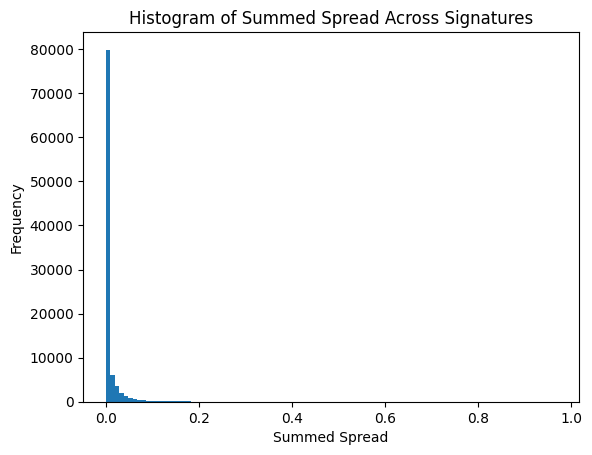

In [18]:
plt.hist(sig_df["summed_spread"], bins=100)
plt.xlabel("Summed Spread")
plt.ylabel("Frequency")
plt.title("Histogram of Summed Spread Across Signatures")
plt.show()

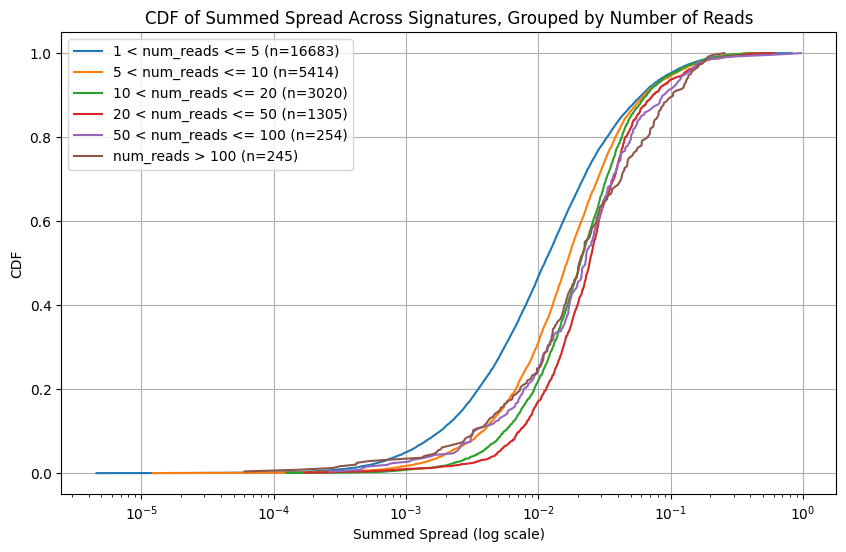

In [19]:
# CDF of summed spread, without the signatures with a single read, and grouping 
# signatures with reads <= 5, <= 10, <= 20, <= 50, <= 100, > 100
plt.figure(figsize=(10, 6))
bounds = [1, 5, 10, 20, 50, 100, np.inf]
eps = 1e-10  # small value to avoid log(0)
for i in range(len(bounds) - 1):
    lower_bound = bounds[i]
    upper_bound = bounds[i + 1]
    if upper_bound == np.inf:
        filtered_sig_df = sig_df.loc[(sig_df["num_reads"] > lower_bound)]
        label = f"num_reads > {lower_bound}"
    else:
        filtered_sig_df = sig_df.loc[(sig_df["num_reads"] > lower_bound) & (sig_df["num_reads"] <= upper_bound)]
        label = f"{lower_bound} < num_reads <= {upper_bound}"
    sorted_spread = np.sort(filtered_sig_df["summed_spread"])
    sorted_spread = sorted_spread[sorted_spread > 0]  # remove zeros to avoid log(0)
    cdf = np.arange(1, len(sorted_spread) + 1) / len(sorted_spread)
    label = f"{label} (n={len(sorted_spread)})"
    plt.plot(sorted_spread, cdf, label=label)
plt.xlabel("Summed Spread (log scale)")
plt.ylabel("CDF")
plt.title("CDF of Summed Spread Across Signatures, Grouped by Number of Reads")
plt.legend()
plt.grid()
plt.xscale("log")
plt.show()

In [20]:
tmp = sig_df["num_reads"].value_counts()


In [21]:
print(
    f"{(sig_df['summed_spread'] == 0).sum()} signatures have a summed spread of 0"
    f" out of {len(sig_df)} total signatures"
    f" ({(sig_df['summed_spread'] == 0).mean() * 100:.2f}%)"
)

69691 signatures have a summed spread of 0 out of 96612 total signatures (72.13%)
